# 3. 静态量化

- 训练后静态量化(Post-Training Static Quantization)是PyTorch Eager模式下的一种量化技术，它通过在模型训练完成后将权重和激活从FP32转换为INT8来实现模型压缩和加速。

## 3.1. 静态量化相关AIPI说明

### (1) 静态量化的应用场景

- 核心特点：
    - **不需要重新训练模型**：直接在预训练好的模型上进行
    - **需要校准数据**：少量无标签数据用于统计激活值的分布
    - **权重量化**：直接量化，无需数据
    - **激活量化**：需要校准数据确定scale和zero_point

- 训练后静态量化的作用
    - **模型压缩**
        - 将32位浮点数转为8位整数，模型大小减少约4倍，例如：100MB的模型压缩后约25MB
    - **推理加速**
        - INT8计算比FP32快2-4倍，特别适合CPU和移动端部署，减少内存带宽占用
    - **功耗降低**
        - 整数运算功耗更低，适合边缘设备和物联网场景
    - **保持精度**
        - 通常精度损失在1-2%以内
        - 某些场景下甚至可以忽略不计
    - 注意：上面这些作用，比动态量化更加满足需求。 

- 训练后静态量化有如下应用场景：
    - 移动端部署
        - 手机APP中的图像识别
        - 实时视频处理
    - 边缘计算
        - 物联网设备推理
        - 嵌入式系统
    - 云端服务降本
        - 降低服务器算力成本
        - 提高吞吐量
    - 实时推理系统
        - 自动驾驶感知
        - 工业质检

- 训练后静态量化的注意事项：
    - 选择合适的后端
        - x86/服务器: 'fbgemm'
        - ARM/移动端: 'qnnpack'
    - 校准数据选择
        - 100-1000张代表性样本
        - 覆盖主要的数据分布
    - 融合操作顺序
        - 先融合，再量化准备
        - 确保融合正确
    - 精度验证
        - 量化前后对比精度
        - 必要时回退某些层不量化
    - 性能测试
        - 测试实际推理速度
        - 检查内存占用

- 训练后静态量化是PyTorch中最成熟、最易用的量化方案，特别适合需要快速部署且对精度要求不是极致的场景。通过合理配置和校准，可以在保持较高精度的同时获得显著的性能提升。

### (2) 训练后静态量化相关的API结构

- 训练后静态量化
    - 占位符模块类
    	- torch.ao.quantization.QuantStub：【在模型中标记量化起点，将FP32张量转换为量化张量。】
    	- torch.ao.quantization.DeQuantStub：【在模型中标记反量化终点，将量化张量转换回FP32。】
    - 准备和转换函数
    	- torch.ao.quantization.fuse_modules：【将多个连续模块融合为一个模块，减少量化误差。】
    	- torch.ao.quantization.prepare：【准备模型进行量化，插入观测器收集统计信息。】
    	- torch.ao.quantization.convert：【将准备好的模型转换为实际的量化模型。】
    - 配置类与相关函数
        - torch.ao.quantization.get_default_qconfig：【获取指定后端的默认量化配置。】
        - torch.ao.quantization.QConfig：【定义量化的配置，包括激活和权重的量化方式。】
    - 观察器类与相关函数
        - torch.ao.quantization.observer.MinMaxObserver：【记录张量的最小值和最大值。】
        - torch.ao.quantization.observer.MovingAverageMinMaxObserver：【使用移动平均更新最小最大值，适合校准过程。】
        - torch.ao.quantization.observer.HistogramObserver：【通过直方图统计更精确的量化参数。】
        - torch.ao.quantization.observer.PerChannelMinMaxObserver：【每通道的量化观测器，常用于卷积层权重。】
        - torch.ao.quantization.add_observer_：【手动为模块添加观测器。】
    - torch预先创建的配置对象：（下面有的在静态量化中不能使用，但是我们还是罗列在此）
        - default_activation_only_qconfig,
        - default_debug_qconfig,
        - default_dynamic_qconfig,
        - default_per_channel_qconfig,
        - default_qat_qconfig,
        - default_qat_qconfig_v2,
        - default_qconfig,
        - default_weight_only_qconfig,
        - float16_dynamic_qconfig,
        - float16_static_qconfig,
        - float_qparams_weight_only_qconfig,
        - per_channel_dynamic_qconfig,

### (3) 占位符类

- QuantStub类
    - 量化存根模块。在校准前，其功能与观察器相同；在转换阶段，它将被替换为`torch.ao.nn.quantized.Quantize`
        - 在校准前，QuantStub 的行为类似于一个观察器（Observer） 。它在模型前向传播中，静静地统计通过它的输入张量的数据范围（如最小值和最大值），为后续的量化参数计算收集必要的统计信息。
        - 在转换阶段就是量化器。
    - 直接父类：
        - `torch.nn.modules.module.Module`类
    - 构造器：
        - `QuantStub(qconfig: typing.Optional[torch.ao.quantization.qconfig.QConfig] = None)`
    - 关键成员函数：
        - `forward(self, x: torch.Tensor) -> torch.Tensor`
        - `__call__ `

- DeQuantStub类
    - 反量化存根模块。在校准前，其功能与恒等映射相同；在转换阶段，它将被替换为`torch.ao.nn.quantized.DeQuantize`。
    - 直接父类：
        - `torch.nn.modules.module.Module`
    - 构造器：
        - `DeQuantStub(qconfig: Optional[Any] = None)`
    - 关键成员函数：
        - `forward(self, x: torch.Tensor) -> torch.Tensor`
        - `__call__`

In [8]:
from torch.ao.quantization import QuantStub, DeQuantStub
import torch
x = torch.randn(4, 3)
stub = QuantStub()
destub = DeQuantStub()

y = stub(x)  # 等价于 y = stub.forward(x)
print(y == x)
z = destub(x)
print(y == x)

tensor([[True, True, True],
        [True, True, True],
        [True, True, True],
        [True, True, True]])
tensor([[True, True, True],
        [True, True, True],
        [True, True, True],
        [True, True, True]])


### (4) 配置类与相关函数

- 配置类torch.ao.quantization.qconfig.QConfig
    - 定义量化的配置，包括激活和权重的量化方式。
    - 构造器：
        - `QConfig(activation, weight)`
            - activation指定观察器类型（不是对象），我们在下面专门介绍观察的作用与使用。
            - weight
            - 注意：activation与weight指定观察器类是因为，在preparation的时候，会使用类来多次为网络的每层生成不同对象。 
    - 数据：
        - activation
        - weight

- torch.ao提供的默认配置：
    - default_activation_only_qconfig：【默认的仅激活值量化 qconfig。】
        - `default_activation_only_qconfig = QConfig(activation=default_fake_quant, weight=torch.nn.Identity)`
    - default_debug_qconfig：【用于调试的默认 qconfig 配置。】
        - `default_debug_qconfig = QConfig(weight=default_weight_observer, activation=default_debug_observer)`
    - default_dynamic_qconfig：【默认的动态 qconfig。】
        - `default_dynamic_qconfig = QConfig(activation=default_dynamic_quant_observer, weight=default_weight_observer)`
    - default_per_channel_qconfig：【用于每通道权重量化的默认 qconfig 配置。】
        - `default_per_channel_qconfig = QConfig(activation=default_observer, weight=default_per_channel_weight_observer)`
    - default_qat_qconfig：【用于 QAT 的默认 qconfig。】
        - `default_qat_qconfig = QConfig(activation=default_fake_quant, weight=default_weight_fake_quant)`
    - default_qat_qconfig_v2：【default_qat_config 的融合版本，具有性能优势。】
        - `default_qat_qconfig_v2 = QConfig(activation=default_fused_act_fake_quant, weight=default_fused_wt_fake_quant)`
    - default_qconfig：【默认的 qconfig 配置】
        - `default_qconfig = QConfig(activation=default_observer, weight=default_weight_observer)`
    - default_weight_only_qconfig：【默认的仅权重量化 qconfig。】
        - `default_weight_only_qconfig = QConfig(activation=torch.nn.Identity, weight=default_weight_fake_quant)`
    - float16_dynamic_qconfig：【动态 qconfig，其权重被量化为 torch.float16。】
        - `float16_dynamic_qconfig = QConfig(activation=PlaceholderObserver.with_args(dtype=torch.float16, is_dynamic=True), weight=PlaceholderObserver.with_args(dtype=torch.float16),)`
    - float16_static_qconfig：【静态 qconfig，其激活值和权重均被量化为 torch.float16。】
        - `float16_static_qconfig = QConfig(activation=PlaceholderObserver.with_args(dtype=torch.float16), weight=PlaceholderObserver.with_args(dtype=torch.float16),)`
    - float_qparams_weight_only_qconfig：【动态 qconfig，其权重量化时使用浮点类型的零点。】
        - `float_qparams_weight_only_qconfig = QConfig(activation=default_placeholder_observer, weight=default_float_qparams_observer)`
    - per_channel_dynamic_qconfig：【动态 qconfig，其权重按每通道进行量化。】
        - `per_channel_dynamic_qconfig = QConfig(activation=default_dynamic_quant_observer, weight=default_per_channel_weight_observer,)`

- 还可以使用get_default_qconfig函数获取指定后端的最优量化配置。
    - `get_default_qconfig(backend='x86', version=0)`
        - backend可以指定`x86` (default), `fbgemm`, `qnnpack` 和 `onednn`。

- **提示**：
    - QConfig总是用来对应网络层设置网络层的量化方式。在与量化相关的函数中，使用QConfig指定网络层的量化方式。比如：
        - quantize_dynamic的qconfig_spec参数。
        - QuantStub的构造器qconfig参数。
        - 在model中的qconfig属性等。

In [1]:
from torch.ao.quantization import QConfig, get_default_qconfig, default_per_channel_qconfig
from torch.ao.quantization.observer import MovingAverageMinMaxObserver, HistogramObserver

qconfig1 = QConfig(activation=MovingAverageMinMaxObserver, weight=HistogramObserver)
qconfig2 = default_per_channel_qconfig
qconfig3 = get_default_qconfig("fbgemm")
print(qconfig1)
print(qconfig2)
print(qconfig3)

QConfig(activation=<class 'torch.ao.quantization.observer.MovingAverageMinMaxObserver'>, weight=<class 'torch.ao.quantization.observer.HistogramObserver'>)
QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.MinMaxObserver'>, quant_min=0, quant_max=127){}, weight=functools.partial(<class 'torch.ao.quantization.observer.PerChannelMinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_channel_symmetric){})
QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.HistogramObserver'>, reduce_range=True){}, weight=functools.partial(<class 'torch.ao.quantization.observer.PerChannelMinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_channel_symmetric){})


- 代码说明：
    - 创建配置三种方式：(a)构造器创建；(b)使用框架提供的QConfig对象；(c)使用辅助函数创建不同后端的最优QConfig对象。

### (5) 观察器类

- 在PyTorch的torch.ao.quantization)模块中，观察器（Observer）是量化感知训练（QAT）和训练后量化（PTQ）中的核心组件。它的主要作用是收集和统计张量的动态范围信息（如最小值、最大值、均值等），从而确定量化的最佳缩放因子（scale）和零点（zero_point）。
    - **收集统计数据**
        - 观察器会记录经过它的张量的统计信息（如 min、max、histogram 等），用于后续计算量化参数。
    - **计算量化参数**
        - 根据收集到的统计信息，观察器会计算出合适的 scale 和 zero_point，供量化/反量化操作使用。
    - **模拟量化效果**
        - 在 QAT 中，观察器帮助模型在前向传播时模拟量化带来的信息损失，使模型能够适应量化后的计算环境。
    - **支持多种量化策略**
        - PyTorch 提供了多种观察器实现，支持不同的量化方式（对称/非对称、per-tensor/per-channel 等）。

- 观察器的工作原理：
    - 观察器通常被插入到模型中需要量化的位置（如**激活函数之后**、**权重之前**）。在前向传播时，它会：
        - 记录输入张量的统计信息（不修改张量本身）。
        - 根据配置的量化方式（如对称量化）计算 scale 和 zero_point。
        - 在量化感知训练中，可能还会执行伪量化操作（fake_quantize），模拟量化误差。

- 常见观察器的作用与使用场合：
    - MinMaxObserver：基于观察到的 min/max 值计算量化参数，适合：训练后量化
    - MovingAverageMinMaxObserver：用移动平均更新min/max，更稳定，适合：量化感知训练
    - HistogramObserver：基于直方图选择最佳截断值，适合：需要更精细的量化边界
    - PerChannelMinMaxObserver：对每个通道单独统计min/max，适合：权重的per-channel量化
    - PlaceholderObserver：占位符，不执行实际统计，适合：调试或自定义场景

- 下面通过例子说明观察器的作用与使用：

In [25]:
import torch
from torch.ao.quantization.observer import MinMaxObserver

# 创建观察器实例
observer = MinMaxObserver(dtype=torch.quint8, qscheme=torch.per_tensor_affine)

# 创建一些示例数据
data = torch.randn(4, 10)

# 观察数据（记录统计信息）
print(data)
data_ = observer(data)   # 返回值输入的data
print(data_ == data)

# 获取量化参数
scale, zero_point = observer.calculate_qparams()
print(f"scale: {scale}, zero_point: {zero_point}")
print(torch.finfo(torch.float32).eps)

tensor([[ 0.0086,  0.1949, -1.8433,  0.3885, -1.0219,  1.8615, -0.3908,  1.9894,
         -0.6537,  1.6079],
        [-1.4951, -1.1431,  0.9636,  0.2676,  0.1096,  1.5718,  1.6887, -0.9553,
          0.4883, -0.2160],
        [-1.0934,  0.5731, -1.1607, -1.7368, -2.1336,  1.0203,  0.4570,  0.8686,
          2.4744,  0.0631],
        [-0.8103, -0.6414,  0.2498, -0.1395,  1.1929,  1.1758, -0.6477,  1.8694,
          1.0098,  0.3439]])
tensor([[True, True, True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True, True, True]])
scale: tensor([0.0181]), zero_point: tensor([118], dtype=torch.int32)
1.1920928955078125e-07


- 代码说明：
    - 每个观察器的构造器有共同的参数与个性化的参数。共同参数是：
        - dtype=torch.quint8：指定量化后的张量应该是什么数据类型，这会影响scale和zero_point的计算方式。可选值有(不是每个类型都时候所有场合的，可以通过参考文档，详细了解不同观察器支持的不同类型，比如MinMaxObserver只支持`torch.qint8`与`torch.quint8`):
            - torch.quint8：无符号 8 位整数（0~255），最常用
            - torch.qint8：有符号 8 位整数（-128~127）
            - torch.qint32：32 位整数
            - torch.float16：16 位浮点数
        - qscheme=torch.per_channel_affine：要使用的量化方案
        - reduce_range=False：将量化数据类型的范围减少1位
        - quant_min=None：最小量化值。若未指定，将遵循8位设置。
        - quant_max=None：最大量化值。若未指定，将遵循8位设置。
        - eps=torch.finfo(torch.float32).eps：float32的epsilon值，默认为torch.finfo(torch.float32).eps。
        - is_dynamic=False：设置量化方式是动态量化还是静态量化。
    - 每个观察器对象的核心函数：
        - forward与__call__负责统计数据。
        - calculate_qparams函数负责计算scale与zero_point

- dtype参数说明：
    - dtype的使用建议：
        - **激活值**：通常用**quint8**，因为 ReLU 后的激活值都是非负的
        - **权重**：通常用**qint8**，因为权重可能有正有负
        - **偏置**：通常用**qint32**，需要更高精度
    - 可选值：
        - torch.qint8
        - torch.quint8
        - torch.quint4x2
        - torch.qint32
        - torch.int8
        - torch.uint8
        - torch.int16
        - torch.int32
        - torch.float8_e5m2
        - torch.float8_e4m3fn
        - torch.uint16
    - 不同观察器的dtype设置值：
        - MinMaxObserver，MovingAverageMinMaxObserver（其父类是MinMaxObserver，所以其dtype与MinMaxObserver一致。）
            - torch.qint8
            - torch.quint8
        - PerChannelMinMaxObserver，MovingAveragePerChannelMinMaxObserver，HistogramObserver，PlaceholderObserver
            - torch.qint8
            - torch.quint8
            - torch.int8
            - torch.uint8

In [26]:
from torch.ao.quantization.observer import MinMaxObserver
# 8位无符号整数（常用于激活值）
observer1 = MinMaxObserver(dtype=torch.quint8)
# 8位有符号整数（常用于权重）
observer2 = MinMaxObserver(dtype=torch.qint8)
# 32位整数（较少使用）
observer3 = MinMaxObserver(dtype=torch.float8_e5m2)

- 代码说明：
    - 在语法上，所有类型都可以设置，但是在具体使用的时候，并不是每个类型都适合的。

- qscheme参数说明：
    - 指定量化的具体方案，包括是否对称、是否per-channel等。可选值：
        - torch.per_tensor_affine：per-tensor 非对称量化，适合激活值量化
        - torch.per_tensor_symmetric：per-tensor 对称量化，适合权重量化
        - torch.per_channel_affine：per-channel 非对称量化，适合权重量化（每通道独立scale）
        - torch.per_channel_symmetric：per-channel 对称量化，适合权重量化（每通道独立scale）
    - 对称与非对称的差异主要是计算公式的差异（这个涉及量化的数学原理）：
        - 非对称量化计算：
            - scale = (max - min) / (quant_max - quant_min)
            - zero_point = round(-min / scale)
        - 对称量化计算：
            - scale = max(abs(min), abs(max)) * 2 / (quant_max - quant_min)
            - zero_point = 0

In [27]:
from torch.ao.quantization.observer import MinMaxObserver
import torch
# per-tensor 非对称量化（常用激活值）
observer1 = MinMaxObserver(
    dtype=torch.quint8,
    qscheme=torch.per_tensor_affine
)
# per-tensor 对称量化（常用权重）
observer2 = MinMaxObserver(
    dtype=torch.qint8,
    qscheme=torch.per_tensor_symmetric
)
# per-channel 对称量化（卷积层权重常用）
try:
    observer3 = MinMaxObserver(
        dtype=torch.qint8,
        qscheme=torch.per_channel_symmetric
    )
except Exception as e:
    print("不支持：", e)

不支持： MinMaxObserver's qscheme only support torch.per_tensor_symmetric                     and torch.per_tensor_affine.


- 代码说明：
    - qscheme的取值不是对每个观察器都支持，不同观察器支持不同的观察值，在使用的时候需要注意。
    - MinMaxObserver观察器只支持：
        - torch.per_tensor_symmetric
        - torch.per_tensor_affine
    - per_tensor_symmetric是在C++层实现，是C++定义的枚举类型。

- reduce_range参数说明：
    - 某些硬件（如ARM NEON）对8位计算有特殊要求，需要保留一个符号位。设置 reduce_range=True 会将量化范围从 256 个值缩小到 127 个值，避免溢出。
        - reduce_range=False：8-bit 量化范围 0~255（256 个值）
        - reduce_range=True：8-bit 量化范围通常缩小到 0~127 或类似范围
    - 使用场景：
        - 在 ARM 架构的移动设备上部署时设为True
        - 在 x86 服务器上部署时通常设为False

In [28]:
from torch.ao.quantization.observer import MinMaxObserver
import torch
# 为移动设备部署做准备
observer = MinMaxObserver(
    dtype=torch.quint8,
    qscheme=torch.per_tensor_affine,
    reduce_range=True  # 缩小范围以适应 ARM NEON
)

- 代码说明：
    - reduce_range参数不推荐使用，而是使用quant_min与quant_max也可以达到reduce_range的作用。

- quant_min 和 quant_max参数说明：
    - 手动指定量化后的最小值和最大值，覆盖默认值。这允许你自定义量化的数值范围。默认值：
        - quint8：quant_min=0, quant_max=255
        - qint8：quant_min=-128, quant_max=127
    - 使用场景：在下面情况下，需要手工设置；其他情况下，建议不需要设置，可以使用默认值。
        - 某些激活函数输出范围已知（如 tanh 输出 `[-1, 1]`）
        - 需要截断异常值，提高量化精度.
        - 硬件有特殊限制

In [29]:
from torch.ao.quantization.observer import MinMaxObserver
import torch
# 对于 tanh 激活，输出范围是 [-1, 1]
observer = MinMaxObserver(
    dtype=torch.qint8,
    qscheme=torch.per_tensor_symmetric,
    quant_min=-127,  # 不使用 -128，避免不对称
    quant_max=127
)

# 对于 ReLU6，输出范围是 [0, 6]
observer = MinMaxObserver(
    dtype=torch.quint8,
    qscheme=torch.per_tensor_affine,
    quant_min=0,
    quant_max=255  # 保持 8 位范围
)

# 限制范围以提高小值精度
observer = MinMaxObserver(
    dtype=torch.quint8,
    qscheme=torch.per_tensor_affine,
    quant_min=0,
    quant_max=127  # 只使用一半的量化范围，提高小值的分辨率
)

- factory_kwargs参数：
    - 传递给内部张量创建的额外关键字参数，主要用于设备指定（如 CPU/GPU）和数据类型。

In [30]:
from torch.ao.quantization.observer import MinMaxObserver
import torch
# 在 GPU 上运行观察器
observer = MinMaxObserver(
    dtype=torch.quint8,
    qscheme=torch.per_tensor_affine,
    factory_kwargs={'device': 'cuda', 'dtype': torch.float32}
)

# 在特定设备上计算
data = torch.randn(10, 10, device='cuda')
observer(data)

tensor([[ 1.4036,  1.1216, -0.0392, -1.0654, -0.6666, -1.2451,  0.6545,  0.4190,
         -0.0800, -0.4882],
        [-1.5212,  1.2908, -0.4222,  0.6223, -1.2866, -0.8651, -1.4235,  0.4061,
          1.1899, -0.3080],
        [ 1.0040,  0.1333, -0.4930, -1.2296, -0.0253,  0.1474, -1.8058,  1.0139,
         -1.5595,  0.4873],
        [-0.3322, -1.7803,  1.3931, -1.0721, -1.4303,  0.5314,  0.0595, -0.9103,
         -0.3876, -0.9249],
        [ 0.6274,  0.1383, -0.3504, -1.2575,  0.6232, -0.4362,  0.0724,  0.5429,
          0.4823, -1.4385],
        [-0.7252, -0.8278, -0.5767,  2.1009, -1.0583, -0.2756, -1.2621,  0.0387,
         -1.5645, -0.6703],
        [ 0.3121, -1.3781, -1.0385, -1.4680,  0.3157,  1.4947,  0.8385, -0.4009,
         -0.6454,  0.7248],
        [-0.1665, -0.9174,  2.0500,  1.0660,  1.2808, -1.2577,  1.6849, -0.1394,
          1.1152, -0.1714],
        [-1.5236, -0.2074, -0.3687, -0.2099,  0.9294,  0.9949, -1.6925,  0.2924,
         -1.0376,  0.9055],
        [ 0.1009,  

- 注意：
    - 我们在使用观察器的时候，一般不是构造对象使用，而是使用直接观察器类，框架在量化网络层的时候，会使用观察器类生成观察器对象并使用。
    - 因为我们通常无法直接构建观察器对象，所以很难控制构造器参数，但是观察器类提供了一种机制，可以让开发者影响观察器对象的构建，这种机制就是，提供了两个类方法，用来传递开发者的参数，开发者参数在实际创建对象的时候使用。
        -  with_args = classmethod(_with_args)
        -  with_callable_args = classmethod(_with_callable_args)

In [31]:
from torch.ao.quantization.observer import MinMaxObserver
import torch
# 在 GPU 上运行观察器
cls_observer = MinMaxObserver.with_args(
    dtype=torch.quint8,
    qscheme=torch.per_tensor_affine,
    factory_kwargs={'device': 'cuda', 'dtype': torch.float32}
)
print(cls_observer)
# 构建对象
observer = cls_observer()
print("*" * 100)
print(observer)

# 数据统计
data = torch.randn(10, 10, device='cuda')
observer(data)
print("*" * 100)
print(observer)

functools.partial(<class 'torch.ao.quantization.observer.MinMaxObserver'>, dtype=torch.quint8, qscheme=torch.per_tensor_affine, factory_kwargs={'device': 'cuda', 'dtype': torch.float32}){}
****************************************************************************************************
MinMaxObserver(min_val=inf, max_val=-inf)
****************************************************************************************************
MinMaxObserver(min_val=-2.6494710445404053, max_val=2.934349536895752)


- 代码说明：
    - with_args返回的是MinMaxObserver类。
    - 代码中我们可以看见数据统计后，min-val与max_val的变化。

- 观察器类中没有像配置类一样一共辅助函数get_default_qconfig来创建观察器对象或者观察器类。但是框架提供内置观察器类。
    - default_observer：【静态量化的默认观察器，通常用于调试。】
    - default_placeholder_observer：【默认占位观察器，通常用于torch.float16量化。】
    - default_debug_observer：【默认仅调试观察器。】
    - default_weight_observer：【默认权重观察器】
    - default_histogram_observer：【默认直方图观察器，通常用于训练后量化（PTQ）。】
    - default_per_channel_weight_observer：【默认的每通道权重观察器，通常用于支持每通道权重量化的后端，如fbgemm。】
    - default_dynamic_quant_observer：【动态量化的默认观察器。】
    - default_float_qparams_observer：【浮点零点的默认观察器。】

In [34]:
from torch.ao.quantization.observer import (
    default_debug_observer,
    default_dynamic_quant_observer,
    default_float_qparams_observer,
    default_float_qparams_observer_4bit,
    default_observer,
    default_per_channel_weight_observer,
    default_placeholder_observer,
    default_reuse_input_observer,
    default_weight_observer,
    per_channel_weight_observer_range_neg_127_to_127,
    weight_observer_range_neg_127_to_127,
)

"""
default_observer = MinMaxObserver.with_args(quant_min=0, quant_max=127)
"""
print(default_observer)
print(weight_observer_range_neg_127_to_127)

functools.partial(<class 'torch.ao.quantization.observer.MinMaxObserver'>, quant_min=0, quant_max=127){}
functools.partial(<class 'torch.ao.quantization.observer.MinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_tensor_symmetric, quant_min=-127, quant_max=127, eps=0.000244140625){}


- 代码说明：
    - 这些默认的观察器都是使用with_args定制不同的构建参数。我们在不同的量化模式中具体介绍。

### (6) 准备与转换函数

- 准备与转换函数有：
    - fuse_modules() 函数：将多个连续模块融合为一个模块，减少量化误差。
    - prepare() 函数：准备模型进行量化，插入观测器收集统计信息。
    - convert() 函数：将准备好的模型转换为实际的量化模型。

- fuse_modules() 函数原型定义与参数说明：
    - fuse_modules函数将一系列模块融合成一个单一模块。
    - 仅融合以下几种模块序列，对于其他序列，保持不变。对于上述可融合序列，将**列表中的第一个模块替换为融合后的模块**，并将序列中**其余模块替换为恒等映射**。
        - `[conv, bn]`
        - `[conv, bn, relu]`
        - `[conv, relu]`
        - `[linear, relu]`
        - `[bn, relu]`
        - 注意：上述模块序列中的名称需要替换成model中的实际模块名称。

```python
torch.ao.quantization.fuse_modules.fuse_modules(
    model,   # 包含待融合模块的模型
    modules_to_fuse, # 待融合模块名称的列表的列表。如果只有一个待融合模块列表，则也可以是一个列表，而不是列表的列表。 
    inplace=False, # 指定融合是否在原地对模型进行。类型是布尔值，默认情况下会返回一个新模型。
    fuser_func=<function fuse_known_modules>, #一个函数，接收模块列表作为输入，并输出一个长度相同的融合后模块列表。例如，fuser_func([convModule, BNModule]) 返回列表 [ConvBNModule, nn.Identity()]。默认为 torch.ao.quantization.fuse_modules.fuse_known_modules。
    fuse_custom_config_dict=None)  # 自定义融合配置
```

In [41]:
import torch
import torch.nn as nn
from torch.ao.quantization import fuse_modules
from torch.ao.quantization.fuse_modules import fuse_known_modules

class BasicBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        return x

model = BasicBlock()
print("原始模型结构:")
print(model)

# 融合模块
model.eval()
fuse_modules(model, ['conv1', 'bn1', 'relu1'], inplace=True)
print("\n融合后模型结构-1:")
print(model)
fuse_modules(model, ['conv2', 'bn2', 'relu2'], inplace=True)
print("\n融合后模型结构-2:")
print(model)

# 验证融合结果
print(f"\nconv1的类型: {type(model.conv1)}")  # 应该是融合后的模块

原始模型结构:
BasicBlock(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
)

融合后模型结构-1:
BasicBlock(
  (conv1): ConvReLU2d(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (bn1): Identity()
  (relu1): Identity()
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
)

融合后模型结构-2:
BasicBlock(
  (conv1): ConvReLU2d(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (bn1): Identity()
  (relu1): Identity()
  (conv2): ConvReLU2d(
    (0): Conv2d(64, 64, kernel_size=

- 下面是更加复杂的模块融合例子

In [42]:
import torch
import torch.nn as nn
from torch.ao.quantization import fuse_modules
from torch.ao.quantization.fuse_modules import fuse_known_modules

class DeepNestedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, 3),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        self.layer2 = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(64, 64, 3),
                nn.BatchNorm2d(64),
                nn.ReLU()
            ) for _ in range(3)    # 循环生成3次。
        ])
        
        self.layer3 = nn.ModuleDict({
            'conv': nn.Conv2d(64, 128, 3),
            'bn': nn.BatchNorm2d(128),
            'relu': nn.ReLU()
        })
        
    def forward(self, x):
        x = self.layer1(x)
        for layer in self.layer2:   # 一级模块计算
            x = layer(x)
        x = self.layer3['conv'](x) # 分级模块计算
        x = self.layer3['bn'](x)
        x = self.layer3['relu'](x)
        return x

model = DeepNestedModel()

# 构建复杂的融合路径
fusion_paths = [
    ['layer1.0', 'layer1.1', 'layer1.2'],  # Sequential内部融合
    
    # ModuleList内部的Sequential
    ['layer2.0.0', 'layer2.0.1', 'layer2.0.2'],
    ['layer2.1.0', 'layer2.1.1', 'layer2.1.2'],
    ['layer2.2.0', 'layer2.2.1', 'layer2.2.2'],
    
    # ModuleDict内部的模块
    ['layer3.conv', 'layer3.bn', 'layer3.relu']
]

# 执行融合
model.eval()
fuse_modules(model, fusion_paths, inplace=True)

# 验证融合结果
print("融合后模型结构:")
def print_model_structure(module, prefix=""):
    for name, child in module.named_children():
        full_name = f"{prefix}.{name}" if prefix else name
        print(f"{full_name}: {type(child).__name__}")
        if len(list(child.children())) > 0:
            print_model_structure(child, full_name)

print_model_structure(model)

融合后模型结构:
layer1: Sequential
layer1.0: ConvReLU2d
layer1.0.0: Conv2d
layer1.0.1: ReLU
layer1.1: Identity
layer1.2: Identity
layer2: ModuleList
layer2.0: Sequential
layer2.0.0: ConvReLU2d
layer2.0.0.0: Conv2d
layer2.0.0.1: ReLU
layer2.0.1: Identity
layer2.0.2: Identity
layer2.1: Sequential
layer2.1.0: ConvReLU2d
layer2.1.0.0: Conv2d
layer2.1.0.1: ReLU
layer2.1.1: Identity
layer2.1.2: Identity
layer2.2: Sequential
layer2.2.0: ConvReLU2d
layer2.2.0.0: Conv2d
layer2.2.0.1: ReLU
layer2.2.1: Identity
layer2.2.2: Identity
layer3: ModuleDict
layer3.conv: ConvReLU2d
layer3.conv.0: Conv2d
layer3.conv.1: ReLU
layer3.bn: Identity
layer3.relu: Identity


- 代码说明：
    - 代码中定义了一个通用的打印模型结构的函数print_model_structure。
    - 该代码说明了常见模型结构的融合例子：
        - nn.Sequential
        - nn.ModuleList
        - nn.ModuleDict

- 使用参数fuser_func实现自定义融合的例子：
    - 重要说明：从PyTorch1.8+ 开始，量化相关的API逐渐从torch.quantization迁移到torch.ao.quantization。ao代表 "architecture optimization"（架构优化）。
    - 其中提供了get_fuser_method函数用于根据模块类型获取对应的融合方法。它是实现自动化和可扩展融合机制的关键。
    - get_fuser_method根据下面列表返回 合适的融合方法。

```python
_DEFAULT_OP_LIST_TO_FUSER_METHOD: dict[tuple, Union[nn.Sequential, Callable]] = {
    (nn.Conv1d, nn.BatchNorm1d): fuse_conv_bn,
    (nn.Conv1d, nn.BatchNorm1d, nn.ReLU): fuse_conv_bn_relu,
    (nn.Conv2d, nn.BatchNorm2d): fuse_conv_bn,
    (nn.Conv2d, nn.BatchNorm2d, nn.ReLU): fuse_conv_bn_relu,
    (nn.Conv3d, nn.BatchNorm3d): fuse_conv_bn,
    (nn.Conv3d, nn.BatchNorm3d, nn.ReLU): fuse_conv_bn_relu,
    (nn.Conv1d, nn.ReLU): _sequential_wrapper2(nni.ConvReLU1d),
    (nn.Conv2d, nn.ReLU): _sequential_wrapper2(nni.ConvReLU2d),
    (nn.Conv3d, nn.ReLU): _sequential_wrapper2(nni.ConvReLU3d),
    (nn.Linear, nn.BatchNorm1d): fuse_linear_bn,
    (nn.Linear, nn.ReLU): _sequential_wrapper2(nni.LinearReLU),
    (nn.BatchNorm2d, nn.ReLU): _sequential_wrapper2(nni.BNReLU2d),
    (nn.BatchNorm3d, nn.ReLU): _sequential_wrapper2(nni.BNReLU3d),
    (nn.ConvTranspose1d, nn.BatchNorm1d): fuse_convtranspose_bn,
    (nn.ConvTranspose2d, nn.BatchNorm2d): fuse_convtranspose_bn,
    (nn.ConvTranspose3d, nn.BatchNorm3d): fuse_convtranspose_bn,
}
```

In [56]:
import torch.nn as nn
from torch.ao.quantization.fuser_method_mappings import get_fuser_method
from torch.ao.quantization.fuse_modules import fuse_known_modules
print(fuse_known_modules)
# 1：基本使用 - 模块类型列表
op_list = (nn.Conv2d, nn.BatchNorm2d, nn.ReLU)
fuser_method = get_fuser_method(op_list)
print(fuser_method)
print(f"找到的融合方法: {fuser_method.__name__ if fuser_method else None}")
# 输出: fuse_conv_bn_relu

# 2：不同组合
combinations = [
    (nn.Conv2d, nn.BatchNorm2d),           # Conv + BN
    (nn.Conv2d, nn.BatchNorm2d, nn.ReLU),  # Conv + BN + ReLU
    (nn.Linear, nn.ReLU),                   # Linear + ReLU
    (nn.Conv2d, nn.ReLU),                    # Conv + ReLU
]

for op_list in combinations:
    method = get_fuser_method(op_list)
    if method:
        print(f"{[m.__name__ for m in op_list]} -> {method.__name__}")
    else:
        print(f"{[m.__name__ for m in op_list]} -> 无内置融合方法")
help(get_fuser_method)

<function fuse_known_modules at 0x000002607381CC20>
<function fuse_conv_bn_relu at 0x000002607381C2C0>
找到的融合方法: fuse_conv_bn_relu
['Conv2d', 'BatchNorm2d'] -> fuse_conv_bn
['Conv2d', 'BatchNorm2d', 'ReLU'] -> fuse_conv_bn_relu
['Linear', 'ReLU'] -> fuser_method
['Conv2d', 'ReLU'] -> fuser_method
Help on function get_fuser_method in module torch.ao.quantization.fuser_method_mappings:

get_fuser_method(op_list, additional_fuser_method_mapping=None)
    Get fuser method for the given list of module types.

    Get fuser method for the given list of module types,
    return None if fuser method does not exist



- 代码说明：
    - 其中融合函数fuser_method实现方式是：sequential(m1, m2)

In [63]:
from torch.ao.quantization.backend_config import (
    get_fbgemm_backend_config,
    get_qnnpack_backend_config,
    get_onednn_backend_config
)
# get_fbgemm_backend_config()   # 需要安装fbgemm
# get_qnnpack_backend_config()
# get_onednn_backend_config()

- 代码说明：
    - get_fuser_method函数的additional_fuser_method_mapping参数可以使用上面不同后端得到特殊的融合方法。

In [13]:
import torch.nn as nn
from torch.ao.quantization import fuse_modules
from torch.ao.quantization.fuser_method_mappings import get_fuser_method, fuse_conv_bn
from torch.ao.quantization.fuse_modules import fuse_known_modules
# fuse_known_modules(mod_list, is_qat, additional_fuser_method_mapping=None)
# help(fuse_known_modules)
# help(fuse_conv_bn)
m1 = nn.Conv2d(10, 20, 3).eval()
print(m1.training)
b1 = nn.BatchNorm2d(20).eval()
m2 = fuse_conv_bn(False, m1, b1)
print(m2)
print("*" * 100)
def custom_fuse(oplist, is_qat, mapping_config):
    # print("\t:", oplist)
    # print("\t:", is_qat)
    # print("\t:", mapping_config)
    typelist = tuple(type(op) for op in oplist)  # 必须是元组
    print(typelist)
    user_mothod = get_fuser_method(typelist, mapping_config)
    return [user_mothod(is_qat, oplist[0], oplist[1]), nn.Identity()]

class TestModelAO(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.relu2 = nn.ReLU()
        self.fc = nn.Linear(64 * 222 * 222, 10)
    
    def forward(self, x):
        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x
fusion_list = [
    ['conv1', 'bn1'],         # Conv+BN
    ['conv2', 'relu2']
]
model = TestModelAO()
model.eval()  # 融合只适合eval评估模式。
fuse_modules(model, fusion_list, inplace=True, fuser_func=custom_fuse)
print(model)

False
Conv2d(10, 20, kernel_size=(3, 3), stride=(1, 1))
****************************************************************************************************
(<class 'torch.nn.modules.conv.Conv2d'>, <class 'torch.nn.modules.batchnorm.BatchNorm2d'>)
(<class 'torch.nn.modules.conv.Conv2d'>, <class 'torch.nn.modules.activation.ReLU'>)
TestModelAO(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn1): Identity()
  (relu1): ReLU()
  (conv2): ConvReLU2d(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
  )
  (relu2): Identity()
  (fc): Linear(in_features=3154176, out_features=10, bias=True)
)


- 代码说明：
    - 大家在融合`["conv2d", "bn"]`的时候，因为在eval模式下，BatchNorm会屏蔽掉，所以一般都融合成Conv2d。
    - 在这里的定制融合，还是是通过get_fuser_method用框架中的融合方法。如果想实现真正的融合，还需要mapping_config来实现，在mapping_config中需要创建用户自己的融合网络层类。在torch.ao框架中，已经实现了常见的融合后的网络层类，这些类在`torch.ao.nn.intrinsic`模块类。
    - 我们上面的实现实际上与fuse_known_modules函数类似。不过使用框架提供的融合方式基本上能满足需求了。

- 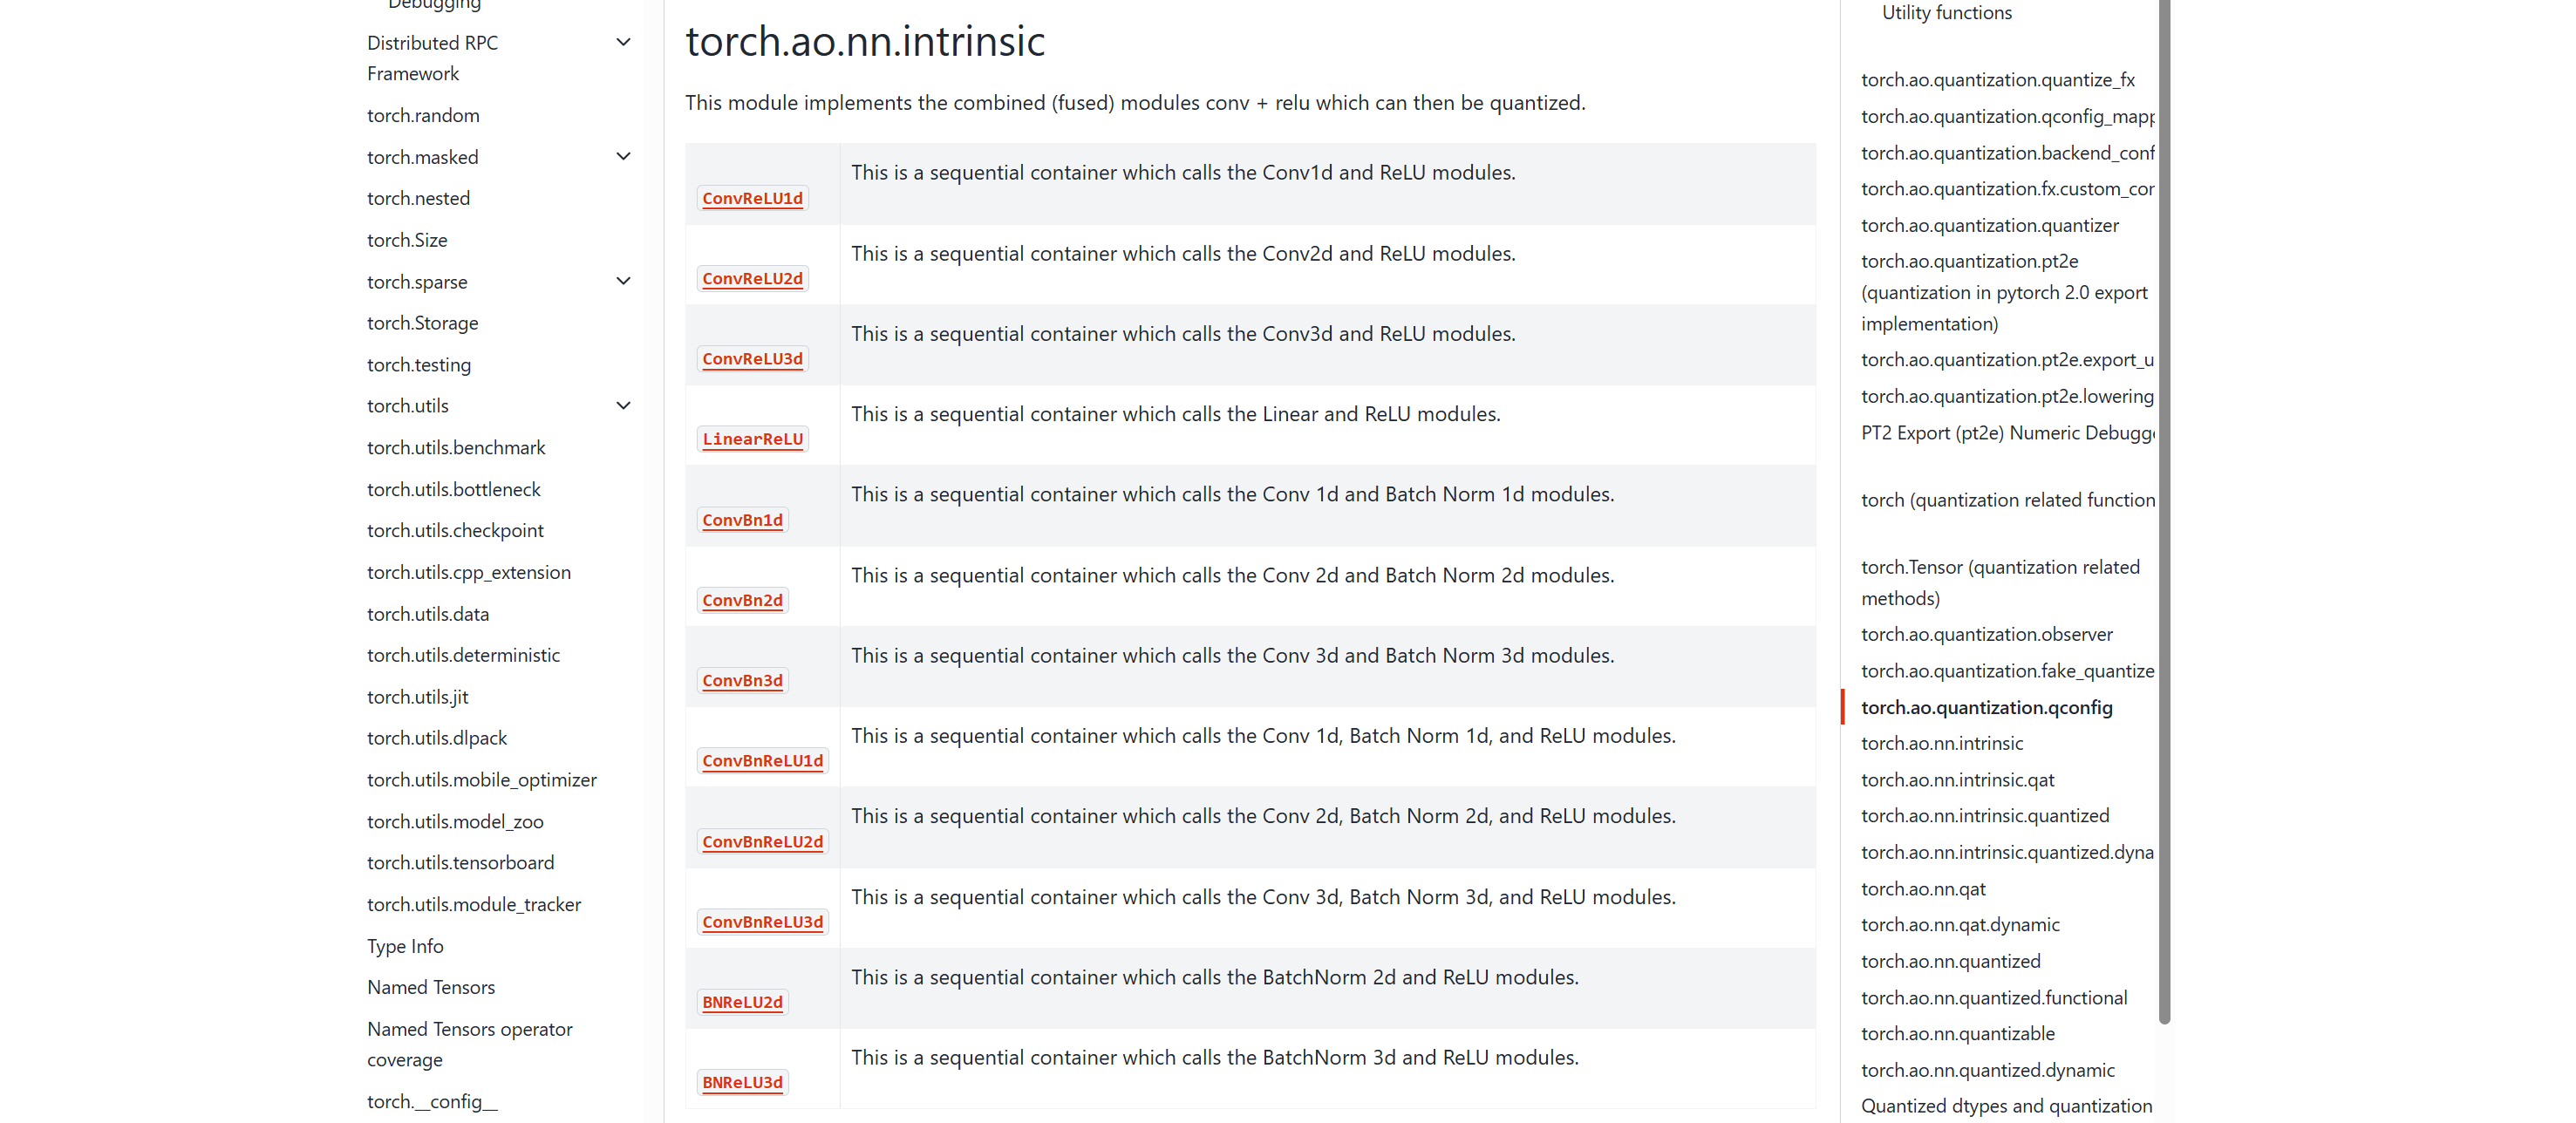

-------

- 上面我们解释清楚了在静态量化中的融合过程，更过的融合技巧还需要在了解量化原理后才能进一步学习。
    - **重要提示**：融合的目的还是提升推理性能。 

- prepare函数说明：
    - prepare是PyTorch.ao量化框架中的核心函数，它负责将浮点模型转换为准备量化的状态。这个函数会在模型中插入观测器(observers)，用于收集激活值和权重的统计信息，为后续的量化转换做准备。。
    - 所以每个网络层都需要定义对应的观察器配置。

- prepare函数原型定义与参数说明：

```python
torch.ao.quantization.prepare(
    model,    # 需要插入观察器的模型
    inplace=False,   # 对模型进行原地转换，即直接修改原始模块。False表示不直接修改，而是使用返回值返回副本。
    allow_list=None, # 可量化模块列表
    observer_non_leaf_module_list=None,  # 想要添加观察器的非叶子模块列表（非终点模块列表）
    prepare_custom_config_dict=None   # prepare函数的自定义配置字典
)
```

- **重点说明**：在prepare函数中，有几个重要过程：
    - (a)会判断model的"qconfig"属性是否存在。并且model.modules()的qconfig属性是否为空，如果都不存在，会报警告。
    - (b)会判断prepare_custom_config_dict是否为空，如果为空会调用get_default_custom_config_dict获取默认的定制配置，并在其中访问"float_to_observed_custom_module_class"字段。
    - (c)会判断allow_list是否为None，如果为None，则会调用get_default_qconfig_propagation_list的带缺省的qconfig_propagation_list。
    - (d)这些条件处理好以后调用_add_observer_函数添加观察器：`_add_observer_(model, qconfig_propagation_list, observer_non_leaf_module_list, custom_module_class_mapping=custom_module_class_mapping,)`

- model的qconfig可以使用get_default_qconfig获取。也可以使用框架预定义的qconfig，比如default_quint8_weight_qconfig。
- 在prepare前，可以使用fuse_modules函数进行模块融合（必须在eval模式下）。

In [20]:
import torch
import warnings
# 忽略警告
warnings.filterwarnings("ignore")

from torch.ao.quantization import get_default_qconfig, prepare
import torch.nn as nn

class TestModelAO(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.relu2 = nn.ReLU()
        self.fc = nn.Linear(64 * 222 * 222, 10)
    
    def forward(self, x):
        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = TestModelAO()
model.eval()
print("*" * 40, "原始模型", "*" * 40)
print(model)
model.qconfig = get_default_qconfig("x86")
print("*" * 40, "添加配置的模型", "*" * 40)
print(model)

###########################################################
# 可选：融合
model_fp32_fused = torch.ao.quantization.fuse_modules(
    model, 
    [
        ['conv1', 'bn1', 'relu1'], 
        ["conv2", "relu2"],
    ],
    inplace=True,
) 
print("*" * 40, "融合的模型", "*" * 40)
print(model)
###########################################################
prepare(
    model, 
    inplace=True,
    allow_list=[
        nn.Conv2d,
        nn.ReLU,
        nn.BatchNorm2d
    ]
)
print("*" * 40, "插入观察器的模型", "*" * 40)
print(model)

**************************************** 原始模型 ****************************************
TestModelAO(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (relu2): ReLU()
  (fc): Linear(in_features=3154176, out_features=10, bias=True)
)
**************************************** 添加配置的模型 ****************************************
TestModelAO(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (relu2): ReLU()
  (fc): Linear(in_features=3154176, out_features=10, bias=True)
)
**************************************** 融合的模型 ****************************************
TestModelAO(
  (conv1): ConvReLU2d(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride

- 代码说明：
    - "x86"配置添加的都是HistogramObserver观察器。
    - 代码中增加了模块融合，可以通过注销，观察融合后模型的观察器情况。融合后BN模块丢失。
    - 代码中使用allow_list指定可以添加观察器模块。不在allow_list中的模块不会添加观察器。
    - 在模型定义中，我们没有使用QuantStub与DeQuantStub。

- observer_non_leaf_module_list参数的使用例子：
    - 该参数也是设置模块列表。

In [24]:
# 示例4：observer_non_leaf_module_list 的使用
class ComplexModel(nn.Module):
    """复杂模型，包含嵌套模块"""
    def __init__(self):
        super().__init__()
        # self.quant = QuantStub()
        # 叶子模块
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.bn1 = nn.BatchNorm2d(32)
        # 非叶子模块（容器）
        self.features = nn.Sequential(
            nn.Conv2d(32, 64, 3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        
        # self.dequant = DeQuantStub()
    
    def forward(self, x):
        # x = self.quant(x)
        x = self.bn1(self.conv1(x))
        x = self.features(x)
        # x = self.dequant(x)
        return x


    
model = ComplexModel()
model.eval()
model.qconfig = torch.ao.quantization.get_default_qconfig('fbgemm')

# 指定非叶子模块也需要插入观测器
observer_non_leaf_list = [
    nn.Sequential,  # 让 Sequential 容器也插入观测器
]

prepared_model = prepare(
    model,
    observer_non_leaf_module_list=observer_non_leaf_list,
    inplace=True
)

# 检查观测器插入情况
print("检查观测器插入情况:")
for name, module in prepared_model.named_modules():
    if hasattr(module, 'activation_post_process'):
        print(f"{name}: 有观测器 - {type(module.activation_post_process).__name__}")
print("*" * 100)
print(prepared_model)

检查观测器插入情况:
conv1: 有观测器 - HistogramObserver
bn1: 有观测器 - HistogramObserver
features: 有观测器 - HistogramObserver
****************************************************************************************************
ComplexModel(
  (conv1): Conv2d(
    3, 32, kernel_size=(3, 3), stride=(1, 1)
    (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
  )
  (bn1): BatchNorm2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
  )
  (features): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
  )
)


- 代码说明：
    - observer_non_leaf_module_list参数指定的非叶子模块会添加一个观察器，该模块的所有紫子模块不会再添加观察器。

- float_to_observed_custom_module_class参数的使用，下面是官方文档提供的范例：
    - CustomModule模型中的模块：可以开发者实现，也可以使用troch.ao官方的实现的模块类。
    - ObservedCustomModule是添加观察器的模块，可以使用官方实现，也可以开发者自己实现。但是必须有from_float类函数完成对象的实例化。

```python
prepare_custom_config_dict = {
    # user will manually define the corresponding observed
    # module class which has a from_float class method that converts
    # float custom module to observed custom module
    "float_to_observed_custom_module_class": {CustomModule: ObservedCustomModule}
}
```

In [53]:
import torch
import torch.nn as nn
import torch.ao.quantization as tq

# 1. 定义自定义观察器模块
class MyObservedConv2d(nn.Module):
    def __init__(self, conv_module, observer=None):
        super().__init__()
        # 复制属性
        self.weight = conv_module.weight
        self.bias = conv_module.bias
        self.stride = conv_module.stride
        self.padding = conv_module.padding
        self.dilation = conv_module.dilation
        self.groups = conv_module.groups
        self.padding_mode = conv_module.padding_mode
        
        # 设置观察器
        if observer is None:
            observer = tq.MovingAverageMinMaxObserver
        self.activation_post_process = observer()
        
        # 复制 qconfig
        if hasattr(conv_module, 'qconfig'):
            self.qconfig = conv_module.qconfig
        
        self.is_observed = True
    
    def forward(self, x):
        x = nn.functional.conv2d(
            x, self.weight, self.bias, self.stride,
            self.padding, self.dilation, self.groups
        )
        if hasattr(self, 'activation_post_process'):
            x = self.activation_post_process(x)
        return x
    
    @classmethod
    def from_float(cls, float_module, observer=None):
        """必须实现的类方法"""
        # print("from_float:", cls, float_module)
        # print(cls(float_module, observer))
        return cls(float_module, observer)

# 3. 使用示例
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(3, 16, 3)
        self.fc = nn.Linear(16 * 6 * 6, 10)
    
    def forward(self, x):
        x = self.conv(x)
        x = torch.relu(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# 创建模型
model = MyModel()
custom_config = {
    # 浮点模块 -> 观察模块映射
    'float_to_observed_custom_module_class': {
        nn.Conv2d: MyObservedConv2d,
    },
}
# 设置 qconfig
model.qconfig = tq.get_default_qconfig('x86')

# 准备量化（这里会自动使用我们注册的 MyObservedConv2d）
prepare(
    model,
    prepare_custom_config_dict=custom_config,
    inplace=True
)

print(model2)

MyModel(
  (conv): MyObservedConv2d(
    (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
  )
  (fc): Linear(
    in_features=576, out_features=10, bias=True
    (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
  )
)


- 代码说明：
    - prepare_custom_config_dict参数目前只支持`float_to_observed_custom_module_class`字段，用来实现定制的层插入。如果想实现自己的量化方案，可以使用该参数来完成。尽管我们大部分情况不使用该参数，但是我们还是想通过该技巧的介绍，让大家知道可以实现用户自己的量化实现。

- 在convert之前，prepare之后，可以提供一些样本数据，调用模型进行推理，并完成校准。

In [56]:
# 示例4：observer_non_leaf_module_list 的使用
class ComplexModel(nn.Module):
    """复杂模型，包含嵌套模块"""
    def __init__(self):
        super().__init__()
        # self.quant = QuantStub()
        # 叶子模块
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.bn1 = nn.BatchNorm2d(32)
        # 非叶子模块（容器）
        self.features = nn.Sequential(
            nn.Conv2d(32, 64, 3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        
        # self.dequant = DeQuantStub()
    
    def forward(self, x):
        # x = self.quant(x)
        x = self.bn1(self.conv1(x))
        x = self.features(x)
        # x = self.dequant(x)
        return x

model = ComplexModel()
model.eval()
model.qconfig = torch.ao.quantization.get_default_qconfig('fbgemm')

# 指定非叶子模块也需要插入观测器
observer_non_leaf_list = [
    nn.Sequential,  # 让 Sequential 容器也插入观测器
]

prepared_model = prepare(
    model,
    observer_non_leaf_module_list=observer_non_leaf_list,
    inplace=False
)

input_fp32 = torch.randn(3, 3, 32, 32)
prepared_model(input_fp32)
print(prepared_model)

ComplexModel(
  (conv1): Conv2d(
    3, 32, kernel_size=(3, 3), stride=(1, 1)
    (activation_post_process): HistogramObserver(min_val=-2.7003650665283203, max_val=2.503326177597046)
  )
  (bn1): BatchNorm2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (activation_post_process): HistogramObserver(min_val=-2.7003514766693115, max_val=2.5033135414123535)
  )
  (features): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (activation_post_process): HistogramObserver(min_val=0.0, max_val=0.6676445603370667)
  )
)


- 代码说明：
    - 注意观察进行数据校准后的观察器，其中min_val与max_val值的变化。

----------

- convert函数说明：
    - convert 是 PyTorch.ao量化模块中的最后一个关键函数，它负责将准备量化的模型（已插入观察器）转换为真正的量化模型。这个函数会根据收集到的统计信息，将浮点权重和激活值转换为整数表示，并替换相应的操作为量化操作。
    - convert函数除了第一个module参数以外，其他参数都是可选的。大部分情况不需要关注除module以外的其他参数。但是我们还是需要讲解这些参数，开发者可以利用这些参数实现一些定制化处理。

- convert函数的原型定义与参数说明：
    - 根据映射关系，通过调用目标模块类上的 from_float 方法，将输入模块中的子模块转换为另一个模块。如果 remove_qconfig 设置为 True，最后将移除 qconfig。
    - 在上面的例子中，我们已经体验到用户定制的模块类的from_float函数的作用。
```python
torch.ao.quantization.convert(
    module,          # 已准备并校准的模块（注意前面模块校准的使用方式）
    mapping=None,    # 一个将源模块类型映射到目标模块类型的字典。该字典可以被覆盖，以允许替换用户自定义的模块。
    inplace=False,   # 对模型进行原地转换，即直接修改原始模块。
    remove_qconfig=True,               # 转换完成后，是否从module中删除qconfig属性“del module.qconfig”
    is_reference=False,                # 启用量化参考模块的标志，mapping非None的时候无效。
    convert_custom_config_dict=None,   # convert函数的自定义配置字典，官方文档提供了一个范例，我们在下面列出。
    use_precomputed_fake_quant=False)  # 启用预计算伪量化功能的标志
```

- convert_custom_config_dict参数的格式范例：

```python
convert_custom_config_dict = {
    # 用户需要手动定义对应的量化模块类，该类需包含一个 from_observed 类方法，用于将经过观察的自定义模块转换为量化后的自定义模块。
    "observed_to_quantized_custom_module_class": {
        ObservedCustomModule: QuantizedCustomModule
    }
}
```

- mapping==None时候，is_reference=True的默认mapping

```python
DEFAULT_REFERENCE_STATIC_QUANT_MODULE_MAPPINGS: dict[Callable, Any] = {
    QuantStub: nnq.Quantize,
    DeQuantStub: nnq.DeQuantize,
    nn.Linear: nnqr.Linear,
    nn.Conv1d: nnqr.Conv1d,
    nn.Conv2d: nnqr.Conv2d,
    nn.Conv3d: nnqr.Conv3d,
    nn.ConvTranspose1d: nnqr.ConvTranspose1d,
    nn.ConvTranspose2d: nnqr.ConvTranspose2d,
    nn.ConvTranspose3d: nnqr.ConvTranspose3d,
    nn.Embedding: nnqr.Embedding,
    nn.EmbeddingBag: nnqr.EmbeddingBag,
    nn.GRUCell: nnqr.GRUCell,
    nn.LSTMCell: nnqr.LSTMCell,
    nn.RNNCell: nnqr.RNNCell,
    nn.LSTM: nnqr.LSTM,
}
```

- mapping==None时候，is_reference=False的默认mapping

```python
DEFAULT_STATIC_QUANT_MODULE_MAPPINGS: dict[Callable, Any] = {
    QuantStub: nnq.Quantize,
    DeQuantStub: nnq.DeQuantize,
    nn.BatchNorm2d: nnq.BatchNorm2d,
    nn.BatchNorm3d: nnq.BatchNorm3d,
    nn.Dropout: nnq.Dropout,
    nn.Conv1d: nnq.Conv1d,
    nn.Conv2d: nnq.Conv2d,
    nn.Conv3d: nnq.Conv3d,
    nn.ConvTranspose1d: nnq.ConvTranspose1d,
    nn.ConvTranspose2d: nnq.ConvTranspose2d,
    nn.ConvTranspose3d: nnq.ConvTranspose3d,
    nn.ELU: nnq.ELU,
    nn.Embedding: nnq.Embedding,
    nn.EmbeddingBag: nnq.EmbeddingBag,
    nn.GroupNorm: nnq.GroupNorm,
    nn.Hardswish: nnq.Hardswish,
    nn.InstanceNorm1d: nnq.InstanceNorm1d,
    nn.InstanceNorm2d: nnq.InstanceNorm2d,
    nn.InstanceNorm3d: nnq.InstanceNorm3d,
    nn.LayerNorm: nnq.LayerNorm,
    nn.LeakyReLU: nnq.LeakyReLU,
    nn.modules.linear.NonDynamicallyQuantizableLinear: nnq.Linear,
    nn.Linear: nnq.Linear,
    nn.ReLU6: nnq.ReLU6,
    nn.PReLU: nnq.PReLU,
    # Wrapper Modules:
    nnq.FloatFunctional: nnq.QFunctional,
    # Intrinsic modules:
    nni.BNReLU2d: nniq.BNReLU2d,
    nni.BNReLU3d: nniq.BNReLU3d,
    nni.ConvReLU1d: nniq.ConvReLU1d,
    nni.ConvReLU2d: nniq.ConvReLU2d,
    nni.ConvReLU3d: nniq.ConvReLU3d,
    nni.ConvAdd2d: nniq.ConvAdd2d,
    nni.ConvAddReLU2d: nniq.ConvAddReLU2d,
    nni.LinearReLU: nniq.LinearReLU,
    nni.LinearLeakyReLU: nniq.LinearLeakyReLU,
    nni.LinearTanh: nniq.LinearTanh,
    nniqat.ConvBn1d: nnq.Conv1d,
    nniqat.ConvBn2d: nnq.Conv2d,
    nniqat.ConvBn3d: nnq.Conv3d,
    nniqat.ConvBnReLU1d: nniq.ConvReLU1d,
    nniqat.ConvBnReLU2d: nniq.ConvReLU2d,
    nniqat.ConvBnReLU3d: nniq.ConvReLU3d,
    nniqat.ConvReLU2d: nniq.ConvReLU2d,
    nniqat.ConvReLU3d: nniq.ConvReLU3d,
    nniqat.LinearReLU: nniq.LinearReLU,
    nniqat.LinearBn1d: nnq.Linear,
    # QAT modules:
    nnqat.Linear: nnq.Linear,
    nnqat.Conv2d: nnq.Conv2d,
    nnqat.Conv3d: nnq.Conv3d,
}
```

- use_precomputed_fake_quant参数用来判断from_float函数中是否有use_precomputed_fake_quant参数：
    - 如果有，则use_precomputed_fake_quant会传递给from_float函数调用：
        - `new_mod = qmod.from_float(mod, use_precomputed_fake_quant=use_precomputed_fake_quant)`
    - 否则就直接调用：
        - `new_mod = qmod.from_float(mod)`

- mapping与custom_module_class_mapping与use_precomputed_fake_quant三个参数的关系参数：
    - custom_module_class_mapping参数中指定的量化模块，通过from_observed完成量化实例。
    - mapping参数中指定的量化模块，通过from_float完成量化实例。
        - 如果模块是参考模块(qmod._IS_REFERENCE)，则调用`new_mod = qmod.from_float(mod, weight_qparams)`完成参考量化
        - 如果模块函数from_float中有use_precomputed_fake_quant，则调用`new_mod = qmod.from_float(mod, use_precomputed_fake_quant=use_precomputed_fake_quant)`，否则调用`new_mod = qmod.from_float(mod)`

- 下面使用代码先了解qconfig的使用

In [58]:
from torch.ao.quantization import get_default_qconfig
get_default_qconfig('x86')

QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.HistogramObserver'>, reduce_range=True){}, weight=functools.partial(<class 'torch.ao.quantization.observer.PerChannelMinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_channel_symmetric){})

- mapping参数的使用

In [71]:
import torch
import torch.nn as nn
import torch.ao.quantization as tq
from torch.ao.quantization import fuse_modules, prepare, convert
# 示例3：mapping 参数的高级使用
import torch.ao.nn.quantized as nnq
class BasicModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.quant = QuantStub()
        self.conv = nn.Conv2d(3, 64, 3)
        self.bn = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(64 * 222 * 222, 10)
        self.dequant = DeQuantStub()
    
    def forward(self, x):
        x = self.quant(x)
        x = self.relu(self.bn(self.conv(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        x = self.dequant(x)
        return x


"""演示 mapping 参数的各种用法"""

# 3.1 默认映射查看
print("=== 默认映射 ===")
from torch.ao.quantization.quantization_mappings import get_default_static_quant_module_mappings
default_mapping = get_default_static_quant_module_mappings()

for float_type, quantized_type in list(default_mapping.items()):
    print(f"  {float_type.__name__} -> {quantized_type.__name__}")

# 3.2 自定义映射
print("\n=== 自定义映射 ===")

class MyQuantizedConv2d(nnq.Conv2d):
    """自定义量化卷积"""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.my_custom_attr = "custom"
    
    def extra_repr(self):
        # return super().extra_repr() + f", custom={self.my_custom_attr}"
        return  "MyQuantizedConv2d:" + super().extra_repr() + f", custom={self.my_custom_attr}"

class MyQuantizedLinear(nnq.Linear):
    """自定义量化线性层"""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.custom_scale = 1.0

# 创建自定义映射
custom_mapping = {
    nn.Conv2d: MyQuantizedConv2d,
    nn.Linear: MyQuantizedLinear,
}

# 3.3 使用自定义映射转换
model = BasicModel()
model.eval()
model.qconfig = torch.ao.quantization.get_default_qconfig('fbgemm')

prepared_model = prepare(model)

# 校准
with torch.no_grad():
    for _ in range(5):
        prepared_model(torch.randn(1, 3, 224, 224))

# 使用自定义映射转换
quantized_model = convert(
    prepared_model,
    mapping=custom_mapping,
    inplace=True
)

# 验证自定义映射效果
print("\n自定义映射转换结果:")
for name, module in quantized_model.named_modules():
    if isinstance(module, (MyQuantizedConv2d, MyQuantizedLinear)):
        print(f"  {name}: {type(module).__name__}", module)
        if hasattr(module, 'my_custom_attr'):
            print(f"    自定义属性: {module.my_custom_attr}")
        if hasattr(module, 'custom_scale'):
            print(f"    自定义scale: {module.custom_scale}")


print(quantized_model)


=== 默认映射 ===
  QuantStub -> Quantize
  DeQuantStub -> DeQuantize
  BatchNorm2d -> BatchNorm2d
  BatchNorm3d -> BatchNorm3d
  Dropout -> Dropout
  Conv1d -> Conv1d
  Conv2d -> Conv2d
  Conv3d -> Conv3d
  ConvTranspose1d -> ConvTranspose1d
  ConvTranspose2d -> ConvTranspose2d
  ConvTranspose3d -> ConvTranspose3d
  ELU -> ELU
  Embedding -> Embedding
  EmbeddingBag -> EmbeddingBag
  GroupNorm -> GroupNorm
  Hardswish -> Hardswish
  InstanceNorm1d -> InstanceNorm1d
  InstanceNorm2d -> InstanceNorm2d
  InstanceNorm3d -> InstanceNorm3d
  LayerNorm -> LayerNorm
  LeakyReLU -> LeakyReLU
  NonDynamicallyQuantizableLinear -> Linear
  Linear -> Linear
  ReLU6 -> ReLU6
  PReLU -> PReLU
  FloatFunctional -> QFunctional
  BNReLU2d -> BNReLU2d
  BNReLU3d -> BNReLU3d
  ConvReLU1d -> ConvReLU1d
  ConvReLU2d -> ConvReLU2d
  ConvReLU3d -> ConvReLU3d
  ConvAdd2d -> ConvAdd2d
  ConvAddReLU2d -> ConvAddReLU2d
  LinearReLU -> LinearReLU
  LinearLeakyReLU -> LinearLeakyReLU
  LinearTanh -> LinearTanh
  ConvBn

- 代码说明：
    - 默认映射是指mapping=None的情况。
    - 输出模型显示的是QuantizedConv2d，但是仔细观察最终实例的类型还是定制的类型。

- torch.ao框架中提供的模块默认映射：

```python
from torch.ao.quantization.quantization_mappings import (
    _get_special_act_post_process,
    _has_special_act_post_process,
    _INCLUDE_QCONFIG_PROPAGATE_LIST,
    DEFAULT_DYNAMIC_QUANT_MODULE_MAPPINGS,
    DEFAULT_FLOAT_TO_QUANTIZED_OPERATOR_MAPPINGS,
    DEFAULT_MODULE_TO_ACT_POST_PROCESS,
    DEFAULT_QAT_MODULE_MAPPINGS,
    DEFAULT_REFERENCE_STATIC_QUANT_MODULE_MAPPINGS,
    DEFAULT_STATIC_QUANT_MODULE_MAPPINGS,
    get_default_compare_output_module_list,
    get_default_dynamic_quant_module_mappings,
    get_default_float_to_quantized_operator_mappings,
    get_default_qat_module_mappings,
    get_default_qconfig_propagation_list,
    get_default_static_quant_module_mappings,
    get_dynamic_quant_module_class,
    get_quantized_operator,
    get_static_quant_module_class,
    no_observer_set,
)
```

## 3.2. 静态量化应用

- 尽管我们上面把每个部分的API都详细介绍，但是实际上使用的时候，采用默认参数能工作的很好。

### (1) 图像分类模型量化应用

### (2) 目标侦测模型量化应用

### (3) 文本分类模型量化应用

## 3.3. 静态量化性能分析

### (1) 融合性能分析

### (2) 存储空间域推理速度性能分析